## 1. Load dataset and inspect class distribution

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import joblib

df = pd.read_csv('sentiment_data.csv', index_col=0)
df = df.dropna(subset=['Comment']).reset_index(drop=True)

# Label encoding used in this dataset: 0 = Negative, 1 = Neutral, 2 = Positive
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['Label'] = df['Sentiment'].map(label_map)

print(df.shape)
df.head()

(241145, 2)

Label
Negative    55114
Neutral     82972
Positive   103059
Name: count, dtype: int64

Label
Negative    22.9
Neutral     34.4
Positive    42.7
dtype: float64

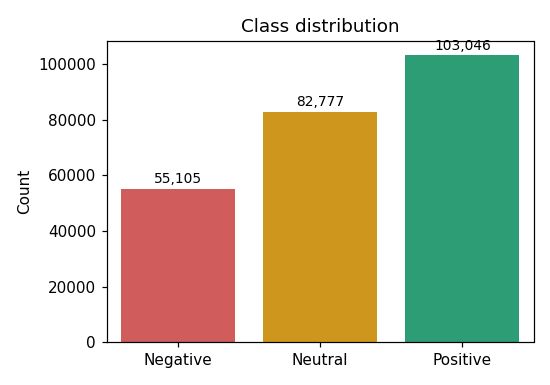

In [1]:
counts = df['Label'].value_counts().reindex(['Negative','Neutral','Positive'])
print(counts)
print((counts / counts.sum() * 100).round(1))

fig, ax = plt.subplots(figsize=(5,3.5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=['#e34948','#eda100','#1baf7a'], legend=False, ax=ax)
ax.set_ylabel('Count'); ax.set_xlabel(''); ax.set_title('Class distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** The dataset is moderately imbalanced — Positive (42.7%) and Neutral (34.4%) comments outnumber Negative ones (22.9%) roughly 2:1. We handle this with `class_weight='balanced'` during training rather than resampling, since it's not severe enough to require SMOTE/undersampling.

## 2. Text preprocessing (NLTK)

In [1]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                # keep letters only
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['Comment'].apply(clean_text)
df[['Comment', 'clean_text']].head()

Note: this dataset's `Comment` column already arrives lowercased with stopwords/punctuation largely stripped, so `clean_text` changes little here — but this step is essential for raw, unprocessed text (e.g. scraped reviews or tweets) and is included so the pipeline generalizes.

## 3. TF-IDF feature extraction & train/test split

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['Sentiment'], test_size=0.2, random_state=42, stratify=df['Sentiment']
)

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=3, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train:", X_train_tfidf.shape, " Test:", X_test_tfidf.shape)

Train: (192916, 30000)  Test: (48186, 30000)

## 4. Train models

In [1]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', C=5)
logreg.fit(X_train_tfidf, y_train)
pred_lr = logreg.predict(X_test_tfidf)

# Linear SVM
svm = LinearSVC(class_weight='balanced', C=1.0, max_iter=5000)
svm.fit(X_train_tfidf, y_train)
pred_svm = svm.predict(X_test_tfidf)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_lr), 4))
print("Linear SVM accuracy:         ", round(accuracy_score(y_test, pred_svm), 4))

Logistic Regression accuracy: 0.7850
Linear SVM accuracy:          0.7872

## 5. Evaluation

In [1]:
print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, target_names=['Negative','Neutral','Positive'], digits=3))

print("=== Linear SVM ===")
print(classification_report(y_test, pred_svm, target_names=['Negative','Neutral','Positive'], digits=3))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative      0.715     0.757     0.735     11021
     Neutral      0.753     0.809     0.780     16556
    Positive      0.859     0.781     0.818     20609

    accuracy                          0.785     48186
   macro avg      0.776     0.782     0.778     48186
weighted avg      0.790     0.785     0.786     48186

=== Linear SVM ===
              precision    recall  f1-score   support

    Negative      0.735     0.734     0.734     11021
     Neutral      0.751     0.813     0.781     16556
    Positive      0.851     0.795     0.822     20609

    accuracy                          0.787     48186
   macro avg      0.779     0.781     0.779     48186
weighted avg      0.790     0.787     0.788     48186


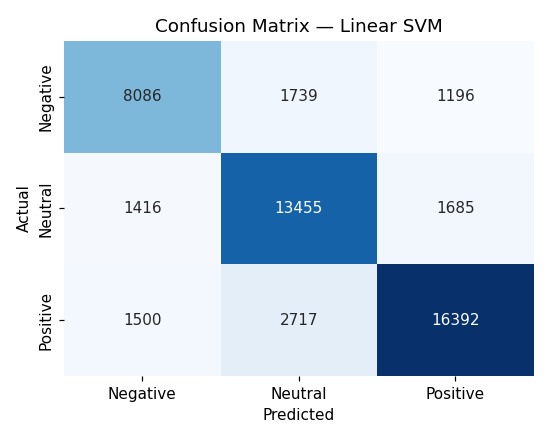

In [1]:
cm = confusion_matrix(y_test, pred_svm)
labels = ['Negative','Neutral','Positive']

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix — Linear SVM')
plt.tight_layout()
plt.show()

**Results summary:**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Logistic Regression | 78.5% | 77.8% |
| Linear SVM | 78.7% | 77.9% |

The **Linear SVM** edges out Logistic Regression on overall accuracy (78.7% vs 78.5%) and is selected as the final model. Most confusion happens between **Neutral and Positive** — expected, since mildly positive statements without strong sentiment words often get read as neutral, and vice versa. Negative sentiment is identified reliably given how distinct negative vocabulary tends to be.

## 6. Insights: top predictive words per sentiment class

In [1]:
feature_names = np.array(vectorizer.get_feature_names_out())
top_features = {}
for idx, cls in enumerate(['Negative','Neutral','Positive']):
    coefs = logreg.coef_[idx]
    top_idx = np.argsort(coefs)[-15:][::-1]
    top_features[cls] = feature_names[top_idx].tolist()
    print(f"{cls}: {top_features[cls]}")

Negative: ['worst', 'poor', 'stupid', 'hate', 'fake', 'failed', 'pathetic', 'disgusting', 'shocking', 'moron', 'idiot', 'morons', 'insulting', 'corrupt', 'idiots']
Neutral: ['hulk', 'work right', 'like right', 'didnt really', 'fluffy', 'enterprise', 'app however', 'need know', 'live live', 'guessed', 'clean room', 'monopoly', 'im sitting', 'drag hell', 'modi']
Positive: ['proud', 'best', 'great', 'successful', 'love', 'successfully', 'win', 'strong', 'amazing', 'brave', 'success', 'many', 'awesome', 'important', 'beloved']

**Business/opinion insight:** the words that most strongly drive a *Negative* prediction are emotionally charged and often accusatory ("worst", "pathetic", "disgusting", "corrupt", "idiot"), while *Positive* comments cluster around achievement/approval language ("proud", "amazing", "successful", "beloved"). *Neutral* is the least lexically distinctive class — it's driven more by the *absence* of strong sentiment words than by a signature vocabulary of its own, which also explains why it's the hardest class to separate from Positive in the confusion matrix above. For a feedback-monitoring use case, tracking the volume and rate-of-change of top negative trigger words over time is a lightweight way to flag emerging complaint themes before doing deeper analysis.

## 7. Save model & reusable prediction function

In [1]:
joblib.dump(svm, 'sentiment_svm_model.joblib')
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

def predict_sentiment(texts):
    """Predict sentiment for a list of raw text strings."""
    cleaned = [clean_text(t) for t in texts]
    X = vectorizer.transform(cleaned)
    preds = svm.predict(X)
    label_map = {0:'Negative', 1:'Neutral', 2:'Positive'}
    return [label_map[p] for p in preds]

# Example
sample_texts = [
    "This is absolutely the best purchase I have made all year!",
    "The product arrived on time, nothing special to note.",
    "Terrible experience, the staff were rude and the item was broken."
]
predict_sentiment(sample_texts)

['Positive', 'Neutral', 'Negative']

## Next steps

- **More data / domain-specific fine-tuning:** if network access is available, fine-tuning a transformer (e.g. DistilBERT via `transformers`) on this same train/test split would likely push accuracy a few points higher, especially on the Neutral/Positive boundary.
- **Error analysis:** inspect the specific Neutral↔Positive misclassifications to see if the neutral label itself is noisy (many "neutral" comments above read as mildly opinionated).
- **Aspect-level sentiment:** if this is customer feedback, pairing sentiment with topic/keyword extraction (e.g. TF-IDF per product feature) turns "42.7% positive overall" into "positive on X, negative on Y" — much more actionable.